{'model__n_neighbors': 6}


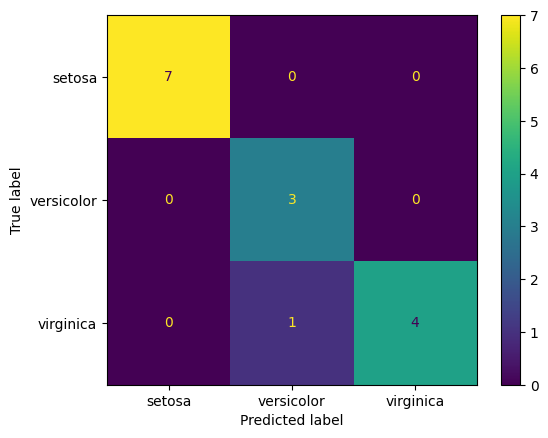

              precision    recall  f1-score   support

      Setosa      1.000     1.000     1.000         7
  Versicolor      0.750     1.000     0.857         3
   Virginica      1.000     0.800     0.889         5

    accuracy                          0.933        15
   macro avg      0.917     0.933     0.915        15
weighted avg      0.950     0.933     0.934        15



In [ ]:
import numpy as np
from sklearn.datasets import load_diabetes, load_iris
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier  
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import pandas as pd

np.random.seed(141)

data = pd.read_csv("iris.csv")

cols_vector = data.columns.to_numpy()

data = np.array(data)

train_size = int(data.shape[0] * 0.9)

train_indices = np.random.choice(data.shape[0], size=train_size, replace=False)
test_indices = np.setdiff1d(np.arange(data.shape[0]), train_indices) #Useful function that takes the array not included above

train_set = data[train_indices,:]
test_set = data[test_indices,:]


X = train_set[:,:4]
y = train_set[:,4]


X_test = test_set[:,:4]
y_test = test_set[:,4]


pipe = Pipeline([("scale", StandardScaler()), 
                 ("model", KNeighborsClassifier(n_neighbors=1))])
#pipe.get_params()

mod = GridSearchCV(estimator=pipe,
             param_grid= {'model__n_neighbors': 
                          [1,2,3,4,5,6,7,8,9,10,11]},
                          cv=3)


mod.fit(X,y)

print(mod.best_params_)

pd.DataFrame(mod.cv_results_)

pred = mod.predict(X_test)

cm = confusion_matrix(y_test, pred)

cr = classification_report(y_test, pred, digits=3)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=load_iris().target_names
)

disp.plot()
plt.show()

print(cr)

# plt.scatter(pred, y)
# plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
# plt.xlabel('Predicted')
# plt.ylabel('True')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

"""
Lets build a KNN algorithm
"""

np.random.seed(141)

data = pd.read_csv("iris.csv")

cols_vector = data.columns.to_numpy()

data = np.array(data)

train_size = int(data.shape[0] * 0.9)

train_indices = np.random.choice(data.shape[0], size=train_size, replace=False)
test_indices = np.setdiff1d(np.arange(data.shape[0]), train_indices) #Useful function that takes the array not included above

train_set = data[train_indices,:]
test_set = data[test_indices,:]



class Classifier_model:
    def __init__(self, observer, predictor, k=3, scale_features=True): #test and train consist of classifier and observation variables
        self.k = k
        self.pred = predictor
        self.obs = observer

        if type(self.obs) == int: #allow for multidimensional input
            self.train = train_set[:, [self.obs, self.pred]]
            self.test = test_set[:, [self.obs, self.pred]]

        else:
            index = self.obs + [self.pred]
            self.train = train_set[:, index]
            self.test = test_set[:, index]

        self.pred_pos = (self.test.shape[1] - 1)
        self.obs_pos = np.arange(self.pred_pos)

        if scale_features == True:
            self.scale_data()

    def scale_data(self):
        # Extract the features as floats
        train_features = self.train[:, self.obs_pos].astype(float)
        test_features = self.test[:, self.obs_pos].astype(float)
        
        # Calculate mean and std ONLY from the training set to prevent data leakage
        mean = np.mean(train_features, axis=0)
        std = np.std(train_features, axis=0)
        
        # Prevent division by zero
        std[std == 0] = 1e-8
        
        # Scale both train and test features
        scaled_train = (train_features - mean) / std
        scaled_test = (test_features - mean) / std
        
        self.train[:, self.obs_pos] = scaled_train
        self.test[:, self.obs_pos] = scaled_test

    def order(self):
            dis = np.zeros((self.test.shape[0], self.k, 2), dtype=object)
            if dis.shape[2] == 2:
                for i in range(self.test.shape[0]):
                    diff = (self.train[:, self.obs_pos] - self.test[i, self.obs_pos]).astype(float)
                    dis_calc = np.sqrt(np.sum(diff **2, axis=1))

                    ord = np.argsort(dis_calc)
                    top_k = ord[:self.k]

                    dis[i, :,0] = dis_calc[top_k]
                    dis[i, :,1] = self.train[top_k, self.pred_pos]

            return(dis)
    
    def KNN(self):
        results = self.order()
        final_results = np.zeros((results.shape[0], 2), dtype=object)
        for i in range(len(results)):
            classes = results[i,:,1]
            unique_classes, counts = np.unique(classes, return_counts=True)
            winning_class = unique_classes[np.argmax(counts)]

            final_results[i, 0] = results[i,:,0].min()
            final_results[i, 1] = winning_class
        
        print(f"Calculated {self.k}{'st' if self.k % 10 == 1 else 'nd' if self.k % 10 == 2 else 'rd' \
                        if self.k % 10 == 3 else 'th'} Nearest Neighbour for {self.test.shape[0]}  {cols_vector[self.obs]} data points")
        return(final_results)
    

    def NB(self): #we use the log of the prior and likelihood to avoid errors in our calcualtions
        classes =  np.unique(self.train[:, self.pred_pos])
        evidence = 1 #this is a constant that doesnt affect the decision and can be ignored

        scores = {} #will use a dictionary for clearer results

        # --- Variance smoothing method used in Scikit-learn to prevent extremely small var or priors ---
        
        # variance of all features across the entire training set
        global_var = np.var(self.train[:, self.obs_pos].astype(float), axis=0)
        
        # fraction of the largest variance
        smoothing_factor = 1e-5 
        var_smoothing = np.max(global_var) * smoothing_factor
        # ---------------------------------------------------------

        for c in classes:
            x_data = self.train[self.train[:,self.pred_pos] == c][:,self.obs_pos].astype(float)
            x_test = self.test[:,self.obs_pos].astype(float)

            prior = x_data.shape[0] / self.train.shape[0]
            log_prior = np.log(prior)

            var = np.var(x_data, axis=0)
            mean = np.mean(x_data, axis=0)


            #As we are using continuous data we use the log of the gaussian PDF
            log_likelihood = -0.5 * np.sum(np.log(2*np.pi*(var + var_smoothing))) \
                  -0.5 * np.sum(((x_test - mean)**2 / (var + var_smoothing)), axis=1)

            joint_log_likelihood = (log_prior + log_likelihood) / evidence

            scores[c] = joint_log_likelihood

        #here we can use pandas to create a data frame of the greatest log likelihood class for each point of data
        df = pd.DataFrame(scores)
        predictions = df.idxmax(axis=1).values
       
        print(f"Calculated Naive Bayes predictions for {self.test.shape[0]} {cols_vector[self.obs]} data points.")
        return(predictions)
    
    
    def confusion_matrix(self, model):
        classes = np.unique(self.test[:, self.pred_pos])
        if model == "KNN":
            pred = self.KNN()[:,1]
        if model == "NB":
            pred = self.NB()
        dim = len(classes)
        matrix = np.zeros((dim, dim)).astype(int)
        act = self.test[:,self.pred_pos]

        for i, c_act in enumerate(classes):

            for j, c_pred in enumerate(classes):

                count = np.sum((pred == c_pred) & (act == c_act))

                matrix[i,j] = count
        
        
        df = pd.DataFrame(matrix, columns= classes, index= classes)
        df.to_csv("confusion_matrix_weather.csv", index=False)

        print(f"Classifier types: {classes}")
        print("--------------------------------------------------------------------------")
        print("(Rows = Actual | Columns = Predicted )")
        print(df)
        print("--------------------------------------------------------------------------")

        accuracy = np.sum(np.diag(matrix)) / np.sum(matrix)
        print(f"Accuracy: {accuracy}")

        return


if __name__ == "__main__":
    run_model = Classifier_model(observer=[0,1,2,3], predictor=4, k=6) 
    run_model.confusion_matrix(model="KNN")

Calculated 6th Nearest Neighbour for 15  ['sepal.length' 'sepal.width' 'petal.length' 'petal.width'] data points
Classifier types: ['Setosa' 'Versicolor' 'Virginica']
--------------------------------------------------------------------------
(Rows = Actual | Columns = Predicted )
            Setosa  Versicolor  Virginica
Setosa           7           0          0
Versicolor       0           3          0
Virginica        0           1          4
--------------------------------------------------------------------------
Accuracy: 0.9333333333333333
